In [66]:
from gerrychain import Graph, Election, Partition, MarkovChain, constraints
from gerrychain.updaters import cut_edges, Tally
from gerrychain.accept import always_accept
from gerrychain.proposals import recom
import matplotlib.pyplot as plt
from functools import partial
import pandas as pd
import numpy as np

In [67]:
graph_pa = Graph.from_file("./PA/PA.shp")

In [68]:
# Total population in the graph
tot_pop = sum(graph_pa.nodes[v]['TOTPOP'] for v in graph_pa.nodes())
tot_pop

13002674.0

In [69]:
elections = [
    Election("PRES24", {"Democratic" : "G24PREDHAR", "Republican" : "G24PRERTRU"}),
    Election("SEN24", {"Democratic" : "G24USSDCAS", "Republican" : "G24USSRMCC"}),
    Election("ATG24", {"Democratic" : "G24ATGDDEP", "Republican" : "G24ATGRSUN"}) 
]

In [70]:
my_updaters = {
    "cut_edges" : cut_edges,
    "population": Tally("TOTPOP", alias="population"),
    "hispanic_population": Tally("HISP", alias="hispanic_population"),
    "black_population": Tally("NH_BLACK", alias="black_population")
}

election_updaters = {
    election.name: election for election in elections
}

my_updaters.update(election_updaters)

In [71]:
initial_partition = Partition(
    graph_pa,
    assignment = "CD",
    updaters = my_updaters
)

In [72]:
num_dist = 17
ideal_pop = tot_pop/num_dist
pop_tolerance = 0.03

# Set up the ReCom proposal for the random walk
random_walk_prop = partial(
    recom, 
    pop_col="TOTPOP",
    pop_target = ideal_pop,
    epsilon= pop_tolerance,
    node_repeats = 2
)

In [73]:
def build_chain(steps):

    population_constraint = constraints.within_percent_of_ideal_population(
        initial_partition, 
        pop_tolerance, 
        pop_key = "population"
    )

    chain = MarkovChain(
        proposal = random_walk_prop,
        constraints = [population_constraint], 
        accept = always_accept,
        initial_state = initial_partition,
        total_steps = steps
    )

    return chain

In [74]:
def chain_results(chain, elections, party="Democratic"):
    results = {}

    for election in elections:
        results[election] = {
            "cut_edges": [],
            "efficiency_gap": [],
            "party_wins": [],
            "party_vote_shares": [],
        }

    results["population"] = {
        "black_majority": [],
        "hispanic_majority": [],
        "max_black_share": [],
        "max_hispanic_share": []
    }

    for part in chain:

        for election in elections:
            results[election]["cut_edges"].append(len(part["cut_edges"]))
            results[election]["efficiency_gap"].append(part[election].efficiency_gap())
            results[election]["party_wins"].append(part[election].wins(party))
            results[election]["party_vote_shares"].append(sorted(part[election].percents(party)))

        black_majority_count = 0
        hispanic_majority_count = 0
        black_shares = []
        hispanic_shares = []

        for district in part.parts:
            total_pop = part["population"][district]

            black_share = part["black_population"][district] / total_pop
            hispanic_share = part["hispanic_population"][district] / total_pop

            black_shares.append(black_share)
            hispanic_shares.append(hispanic_share)

            if black_share > 0.5:
                black_majority_count += 1

            if hispanic_share > 0.5:
                hispanic_majority_count += 1

        results["population"]["black_majority"].append(black_majority_count)
        results["population"]["hispanic_majority"].append(hispanic_majority_count)
        results["population"]["max_black_share"].append(max(black_shares))
        results["population"]["max_hispanic_share"].append(max(hispanic_shares))


    return results

In [75]:
election_names = ["PRES24", "SEN24", "ATG24"]

In [76]:
random_walk_20 = build_chain(20000)
random_walk_40 = build_chain(40000)
random_walk_60 = build_chain(60000)
random_walk_80 = build_chain(80000)
random_walk_100 = build_chain(100000)
random_walk_120 = build_chain(120000)


In [77]:
results_20 = chain_results(random_walk_20, election_names)
results_40 = chain_results(random_walk_40, election_names)
results_60 = chain_results(random_walk_60, election_names)
results_80 = chain_results(random_walk_80, election_names)
results_100 = chain_results(random_walk_100, election_names)
results_120 = chain_results(random_walk_100, election_names)

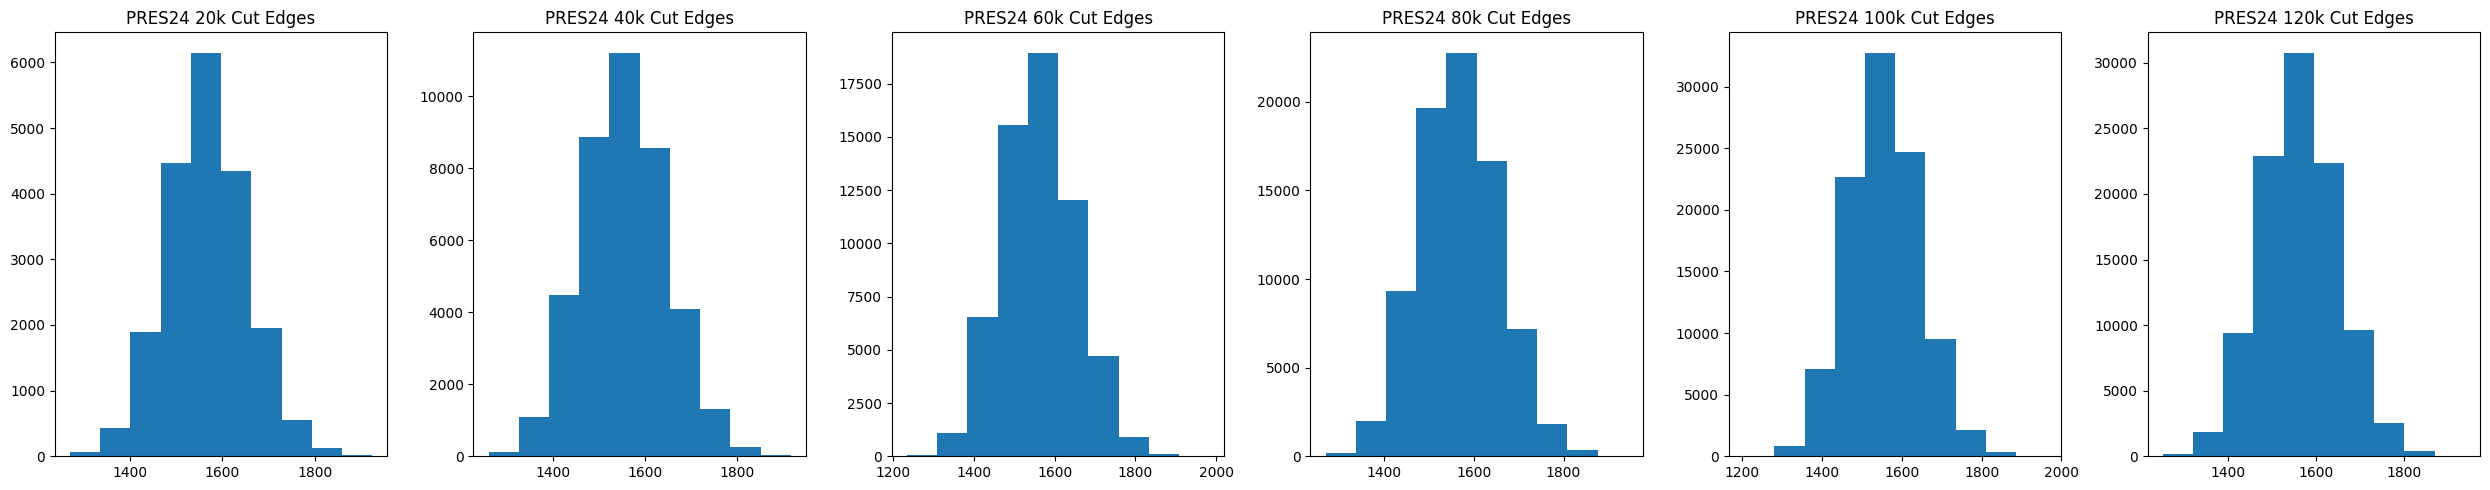

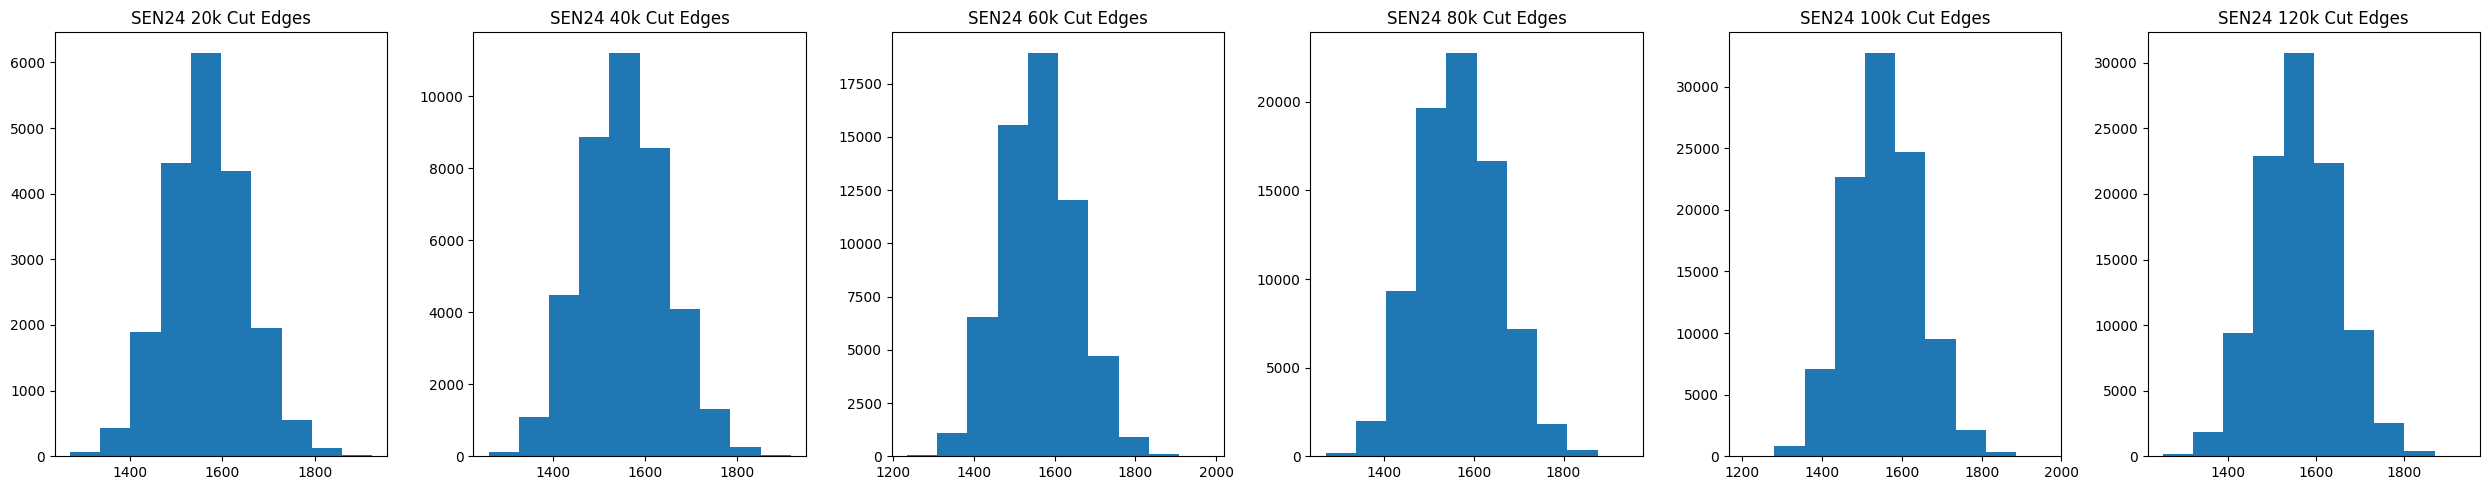

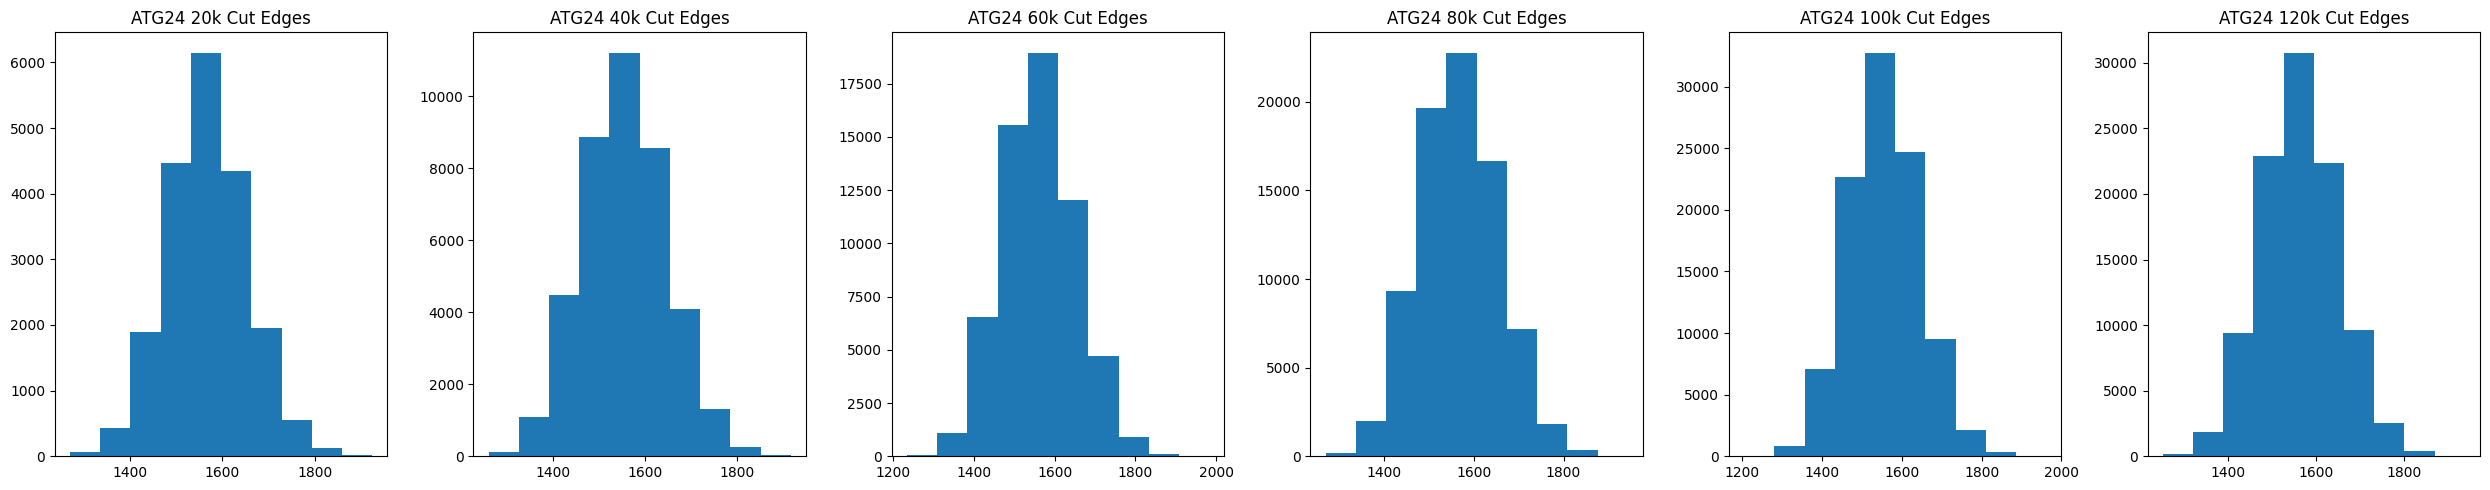

In [78]:
for election in election_names:

    fig, axes = plt.subplots(1, 6, figsize=(25, 5))

    # 20k Steps
    axes[0].hist(results_20[election]["cut_edges"], align='left')
    axes[0].set_title(f"{election} 20k Cut Edges")

    # 40k Steps
    axes[1].hist(results_40[election]["cut_edges"], align='left')
    axes[1].set_title(f"{election} 40k Cut Edges")

    # 60k Steps
    axes[2].hist(results_60[election]["cut_edges"], align='left')
    axes[2].set_title(f"{election} 60k Cut Edges")

    # 80k Steps
    axes[3].hist(results_80[election]["cut_edges"], align='left')
    axes[3].set_title(f"{election} 80k Cut Edges")

    # 100k Steps
    axes[4].hist(results_100[election]["cut_edges"], align='left')
    axes[4].set_title(f"{election} 100k Cut Edges")

    # 100k Steps
    axes[5].hist(results_120[election]["cut_edges"], align='left')
    axes[5].set_title(f"{election} 120k Cut Edges")

    plt.tight_layout()
    plt.show()


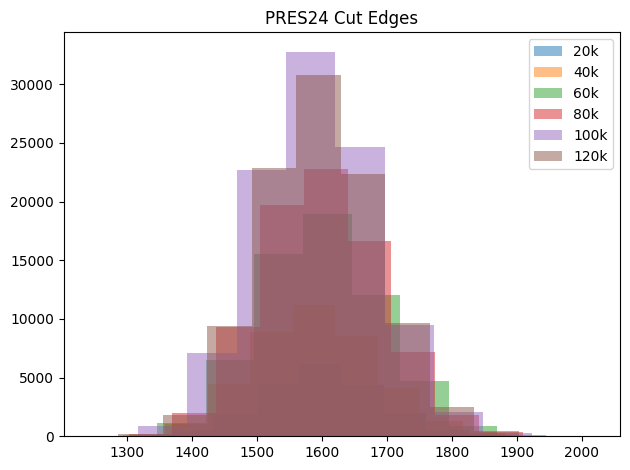

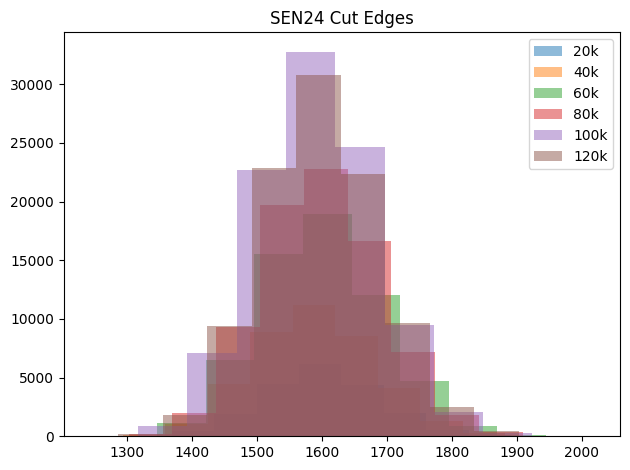

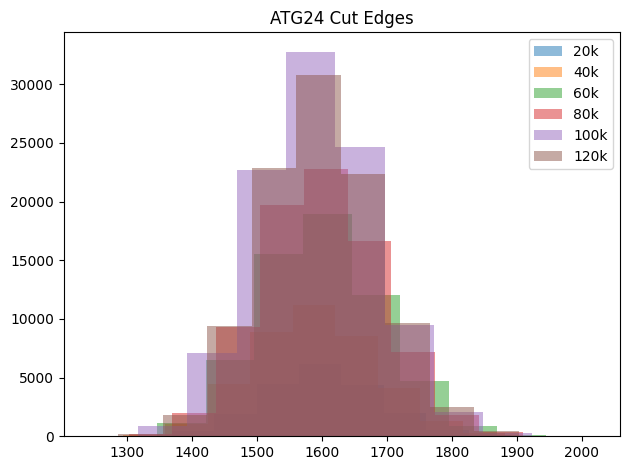

In [ ]:

for election in election_names:
    
    plt.hist(results_20[election]["cut_edges"], alpha=0.5, label="20k")
    plt.hist(results_40[election]["cut_edges"], alpha=0.5, label="40k")
    plt.hist(results_60[election]["cut_edges"], alpha=0.5, label="60k")
    plt.hist(results_80[election]["cut_edges"], alpha=0.5, label="80k")
    plt.hist(results_100[election]["cut_edges"], alpha=0.5, label="100k")
    plt.hist(results_120[election]["cut_edges"], alpha=0.5, label="120k")

    plt.legend()

    plt.title(f"{election} Cut Edges")

    plt.tight_layout()
    plt.show()


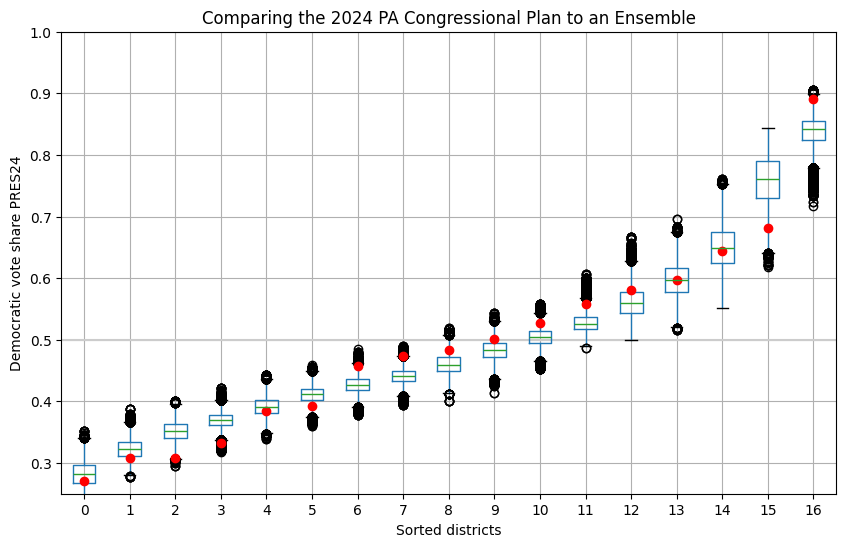

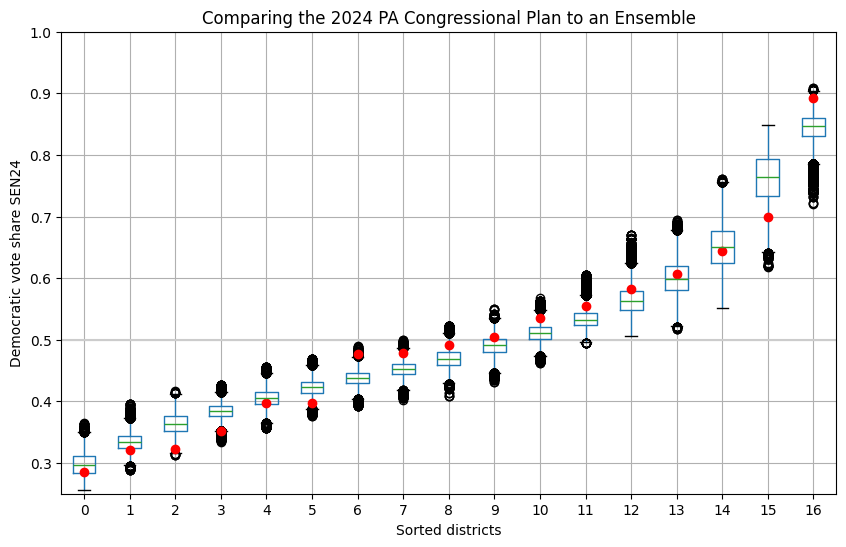

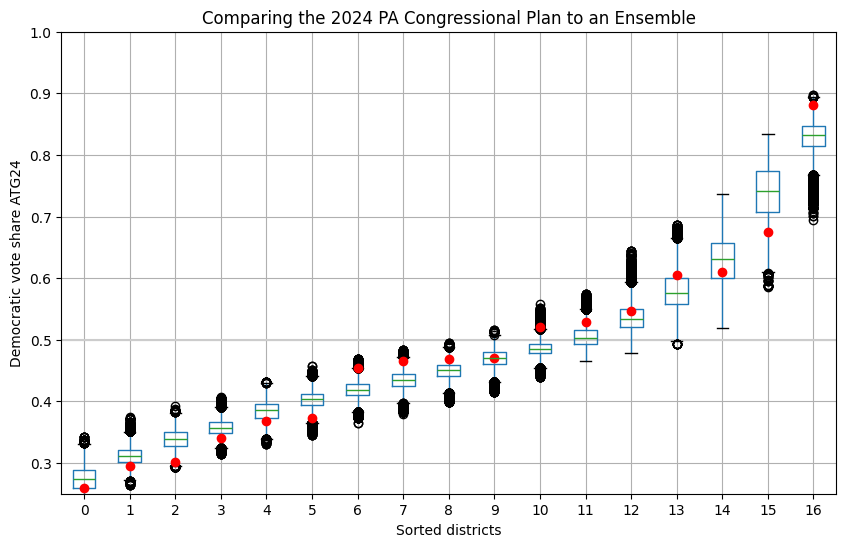

In [90]:
# Using 100k
for election in election_names:
    vote_shares = results_100[election]["party_vote_shares"]

    data = pd.DataFrame(vote_shares)

    fig, ax = plt.subplots(figsize=(10, 6))

    # 50% line
    ax.axhline(0.5, color="#cccccc")

    data.boxplot(ax=ax, positions=range(len(data.columns)))

    # Drawing the Democratic vote share percentage (first row [0])
    current_plan = data.iloc[0]
    ax.plot(range(len(current_plan)), current_plan, "ro")

    ax.set_ylim(0.25, 1)

    ax.set_title("Comparing the 2024 PA Congressional Plan to an Ensemble")
    ax.set_ylabel(f"Democratic vote share {election}")
    ax.set_xlabel("Sorted districts")

    plt.show()

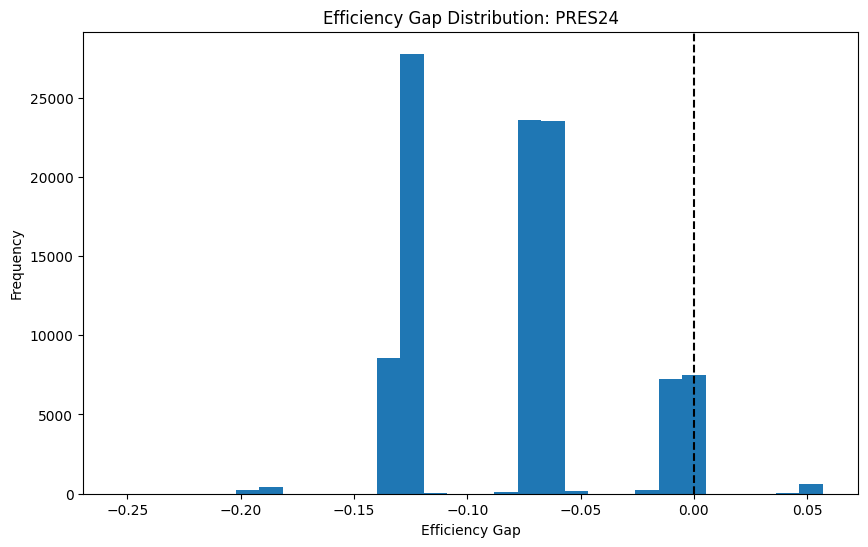

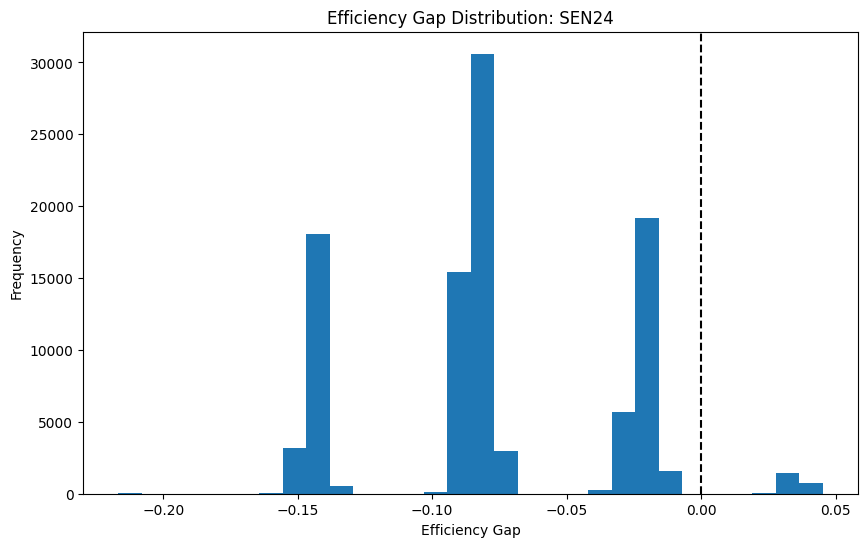

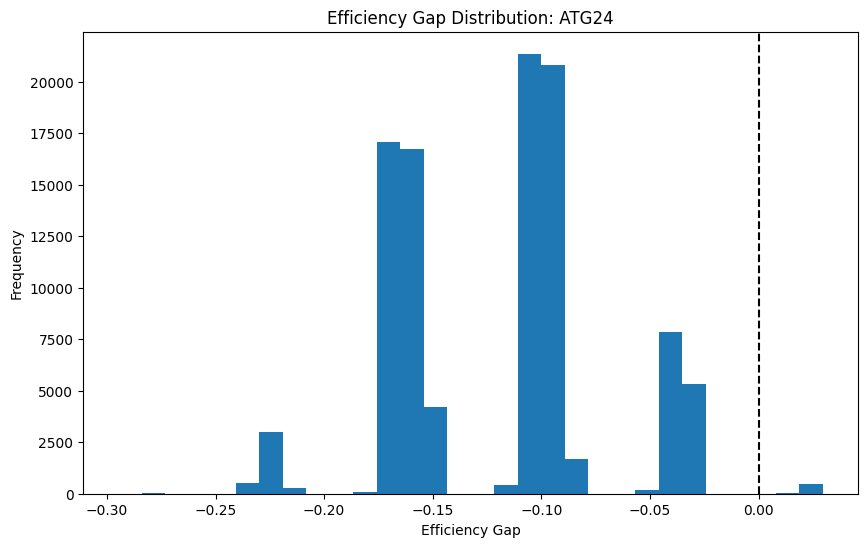

In [91]:
for election in election_names:
    plt.figure(figsize=(10, 6))

    plt.hist(results_100[election]["efficiency_gap"], bins=30)
    plt.axvline(0, color="black", linestyle="--")

    plt.title(f"Efficiency Gap Distribution: {election}")

    plt.xlabel("Efficiency Gap")
    plt.ylabel("Frequency")

    plt.show()

In [92]:
print(initial_partition["PRES24"].wins("Democratic"))
print(initial_partition["PRES24"].wins("Republican"))
print(initial_partition["PRES24"].efficiency_gap())

8
9
-0.005100554235036114


The enseble behavior is relatively stable across statewide elections

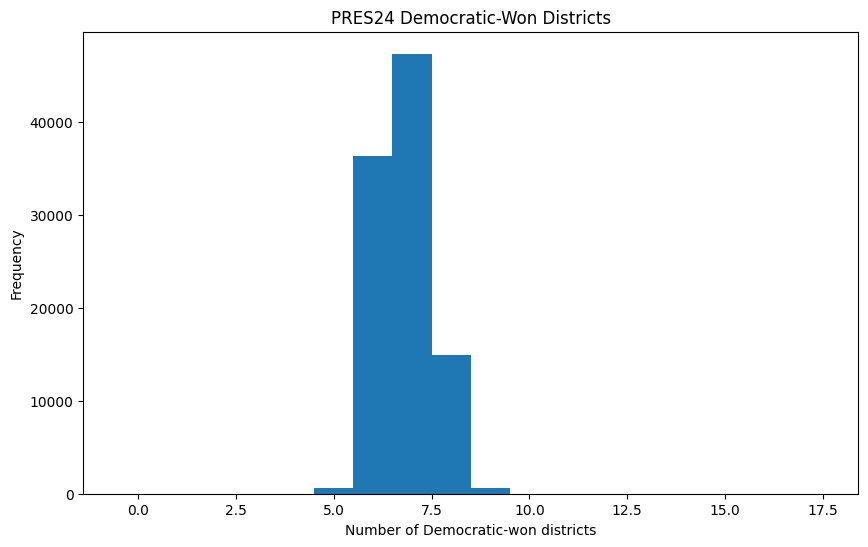

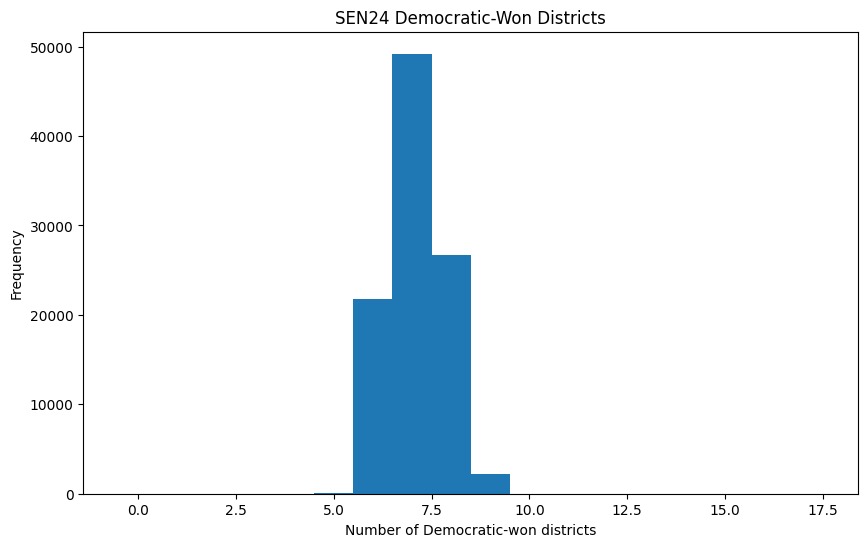

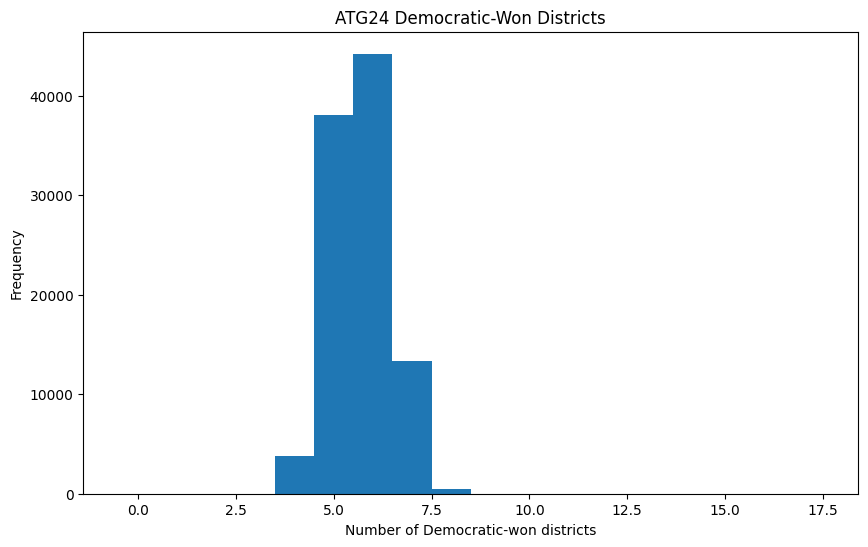

In [93]:
for election in election_names:

    plt.figure(figsize=(10, 6))

    plt.hist(results_100[election]["party_wins"], bins=range(0, 19), align="left")

    plt.title(f"{election} Democratic-Won Districts")
    
    plt.xlabel("Number of Democratic-won districts")
    plt.ylabel("Frequency")

    plt.show()

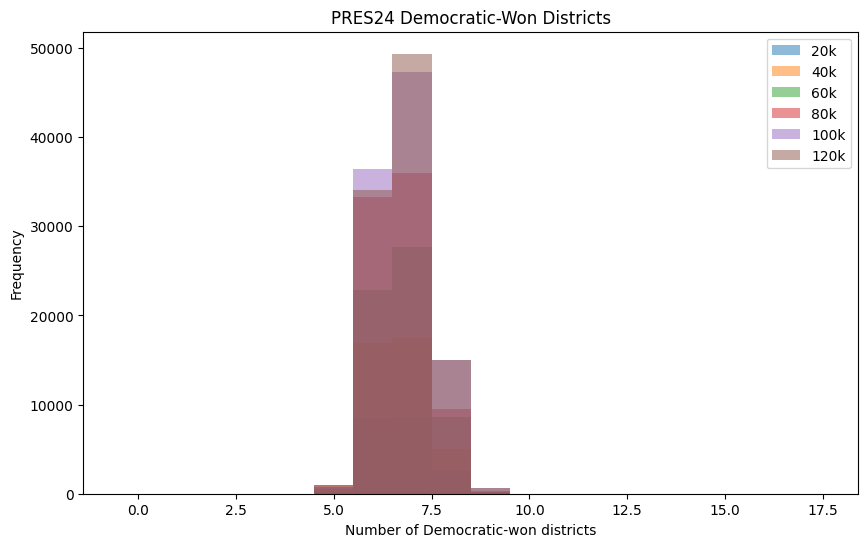

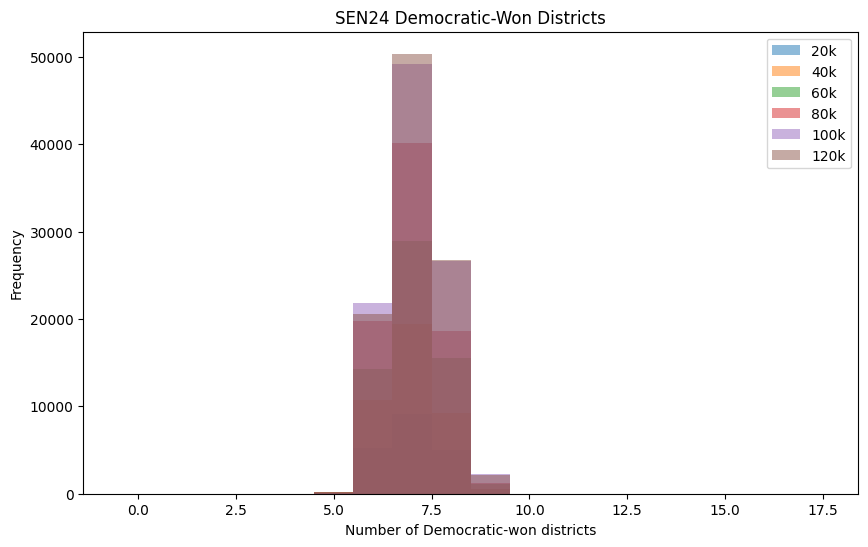

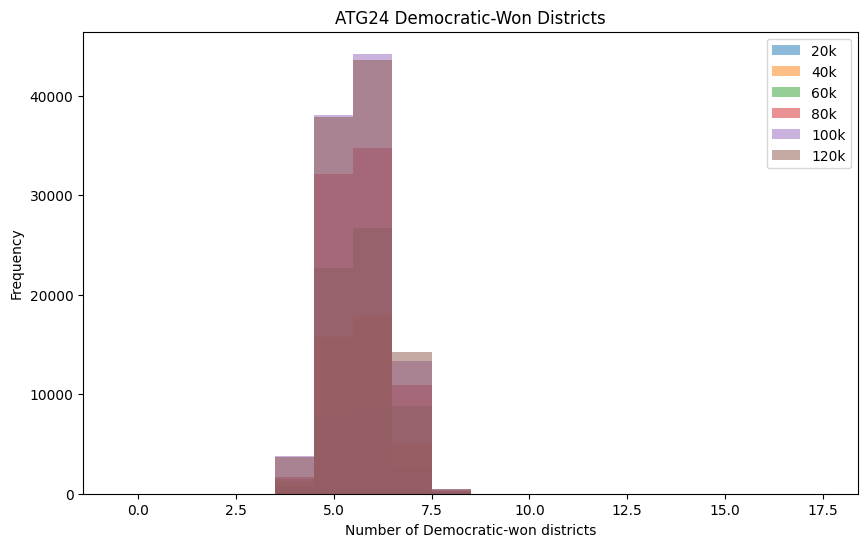

In [94]:
for election in election_names:

    plt.figure(figsize=(10, 6))

    plt.hist(results_20[election]["party_wins"], bins=range(0, 19), alpha=0.5, label="20k", align="left")
    plt.hist(results_40[election]["party_wins"], bins=range(0, 19), alpha=0.5, label="40k", align="left")
    plt.hist(results_60[election]["party_wins"], bins=range(0, 19), alpha=0.5, label="60k", align="left")
    plt.hist(results_80[election]["party_wins"], bins=range(0, 19), alpha=0.5, label="80k", align="left")
    plt.hist(results_100[election]["party_wins"], bins=range(0, 19), alpha=0.5, label="100k", align="left")
    plt.hist(results_120[election]["party_wins"], bins=range(0, 19), alpha=0.5, label="120k", align="left")

    plt.title(f"{election} Democratic-Won Districts")
    plt.xlabel("Number of Democratic-won districts")
    plt.ylabel("Frequency")

    plt.legend()

    plt.show()

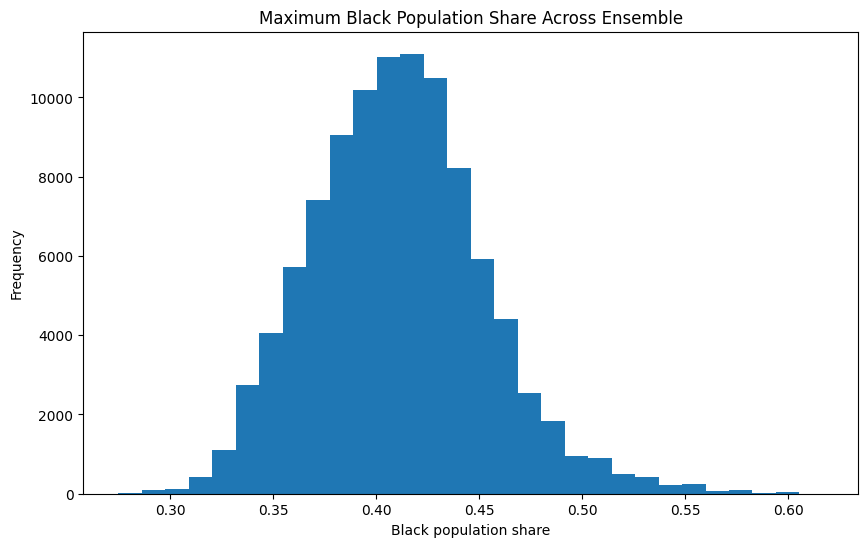

In [95]:
plt.figure(figsize=(10, 6))

plt.hist(results_100["population"]["max_black_share"], bins=30)

plt.title("Maximum Black Population Share Across Ensemble")

plt.xlabel("Black population share")
plt.ylabel("Frequency")

plt.show()

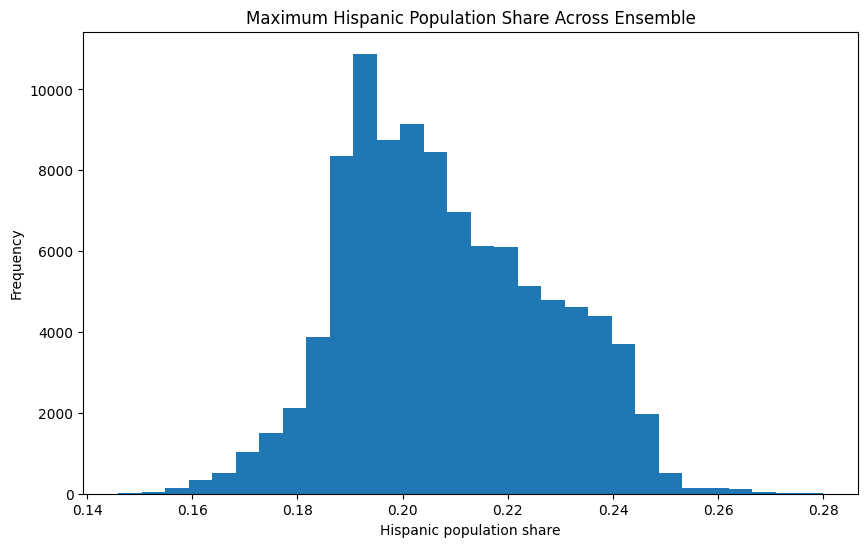

In [96]:
plt.figure(figsize=(10, 6))

plt.hist(results_100["population"]["max_hispanic_share"], bins=30)

plt.title("Maximum Hispanic Population Share Across Ensemble")

plt.xlabel("Hispanic population share")
plt.ylabel("Frequency")

plt.show()

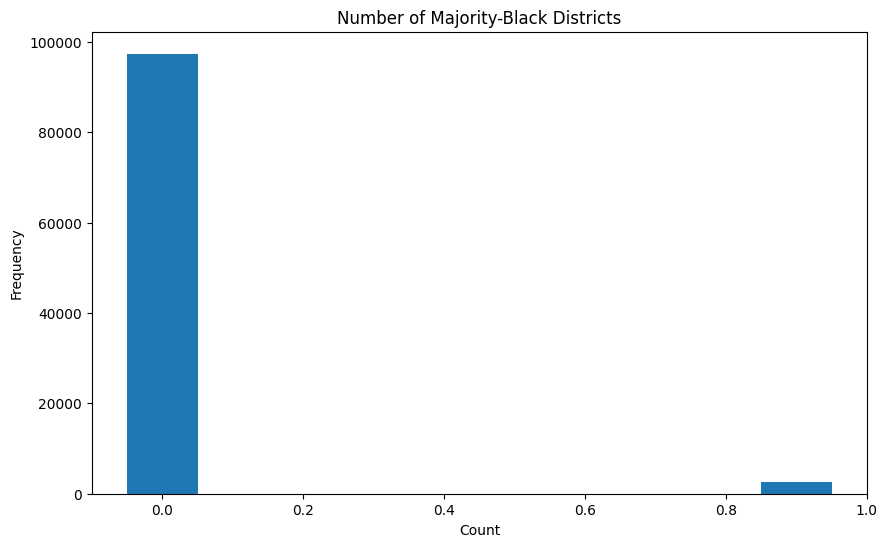

In [97]:
plt.figure(figsize=(10, 6))

plt.hist(results_100["population"]["black_majority"], align="left")

plt.title("Number of Majority-Black Districts")

plt.xlabel("Count")
plt.ylabel("Frequency")

plt.show()

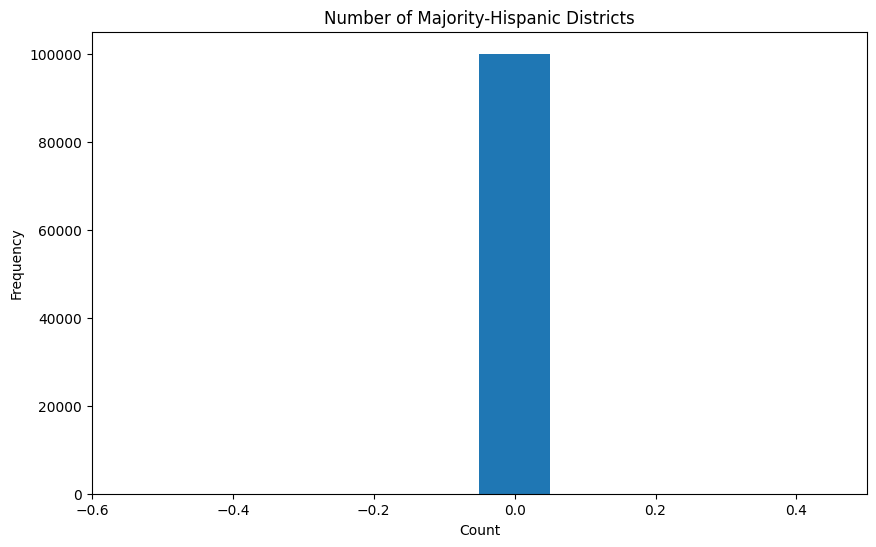

In [98]:
plt.figure(figsize=(10, 6))

plt.hist(results_100["population"]["hispanic_majority"], align="left")

plt.title("Number of Majority-Hispanic Districts")

plt.xlabel("Count")
plt.ylabel("Frequency")

plt.show()

In [99]:
# Checking inital because the chains seem drastic
b_count = 0
h_count = 0

for district in initial_partition.parts:
    total_pop = initial_partition["population"][district]

    black_share = initial_partition["black_population"][district] / total_pop
    hispanic_share = initial_partition["hispanic_population"][district] / total_pop

    if black_share > 0.5:
        b_count += 1

    if hispanic_share > 0.5:
        h_count += 1

print("Original Enacted Plan")
print("Majority Black:", b_count)
print("Majority Hispanic:", h_count)



Original Enacted Plan
Majority Black: 1
Majority Hispanic: 0
